In [15]:
import sys
from pathlib import Path
# make repo self-contained
repo_path = Path.cwd() / "Depth-Anything-V2"
sys.path.append(str(repo_path))
from depth_anything_v2.dpt import DepthAnythingV2

import cv2
import torch
import matplotlib.pyplot as plt
import numpy as np

In [2]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'

model_configs = {
    'vits': {'encoder': 'vits', 'features': 64, 'out_channels': [48, 96, 192, 384]},
    'vitb': {'encoder': 'vitb', 'features': 128, 'out_channels': [96, 192, 384, 768]},
    'vitl': {'encoder': 'vitl', 'features': 256, 'out_channels': [256, 512, 1024, 1024]},
    'vitg': {'encoder': 'vitg', 'features': 384, 'out_channels': [1536, 1536, 1536, 1536]}
}

encoder = 'vits' # or 'vits', 'vitb', 'vitg'
ckpt_path = repo_path / "checkpoints" / f"depth_anything_v2_{encoder}.pth"

model = DepthAnythingV2(**model_configs[encoder])
model.load_state_dict(torch.load(ckpt_path, map_location='cpu'))
model = model.to(DEVICE).eval()

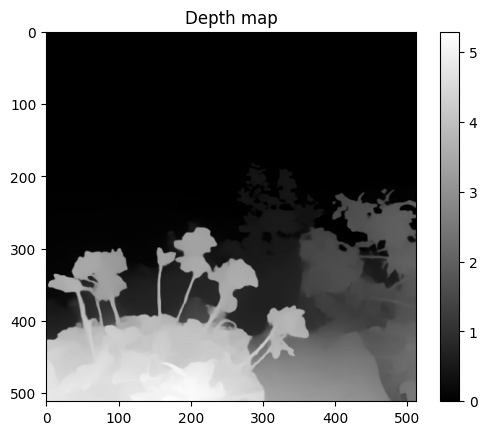

In [7]:
# Read Image
raw_img = cv2.imread(r'C:\Users\maxba\Pictures\Image_Processing_Media\Other\Landscape_RGB_512x512.png')

# Estimate Depth
depth = model.infer_image(raw_img) # HxW raw depth map in numpy

# Display Depth Image
plt.imshow(depth, cmap='gray')
plt.colorbar()
plt.title("Depth map")
plt.show()

In [17]:
# Read Image
raw_img = cv2.imread(r'C:\Users\maxba\Pictures\Image_Processing_Media\Other\Barbara_color_256x256.png')

# Estimate Depth
depth = model.infer_image(raw_img) # HxW raw depth map in numpy

depth_01 = (depth-np.min(depth))/(np.max(depth)-np.min(depth))
cv2.imshow("Depth (0-1 Normalized)", depth_01)
cv2.waitKey(0)
cv2.destroyAllWindows()

# # Display Depth Image
# plt.imshow(depth, cmap='gray')
# plt.colorbar()
# plt.title("Depth map")
# plt.show()

In [11]:
depth.min()

np.float32(0.0045327866)

In [13]:
depth.max()

np.float32(6.365217)